In [14]:
!pip install Pillow

In [15]:
pip install -q rfdetr>=1.4.0 supervision roboflow

In [16]:


import torch
import cv2
import numpy as np
import supervision as sv
from PIL import Image
from tqdm import tqdm
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

# If you have your custom module:
from rfdetr import RFDETRLarge

# ------------------------
# CONFIGURATION
# ------------------------
CHECKPOINT_PATH = "/content/drive/MyDrive/Projects/RoadEye/RFDETR_ROADEYE_Large/Models/checkpoint_best_ema.pth"
CONF_THRESHOLD = 0.4
IMG_SIZE = 640
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Loading models on: {DEVICE}")

# 1. LOAD SEGFORMER (Road Segmentation)
processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-cityscapes-512-1024")
seg_model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-cityscapes-512-1024").to(DEVICE)
seg_model.eval()

# 2. LOAD RF-DETR (Pothole Detection)
det_model = RFDETRLarge(
    num_classes=1,
    pretrain_weights=CHECKPOINT_PATH,
    resolution=IMG_SIZE
)
det_model.optimize_for_inference()

print("✅ Both models loaded successfully!")

Loading models on: cuda


[2026-02-25 09:43:53] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-02-25 09:43:53] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-02-25 09:43:53] [INFO] rf-detr - Loading pretrain weights
✅ Both models loaded successfully!


In [17]:
def get_road_mask(image: Image.Image, processor, model, device):
    """Generates a binary road mask from a PIL Image using Segformer."""
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    # Resize logits to match the original image size
    logits = torch.nn.functional.interpolate(
        logits,
        size=image.size[::-1], # PIL is (W,H), PyTorch expects (H,W)
        mode="bilinear",
        align_corners=False,
    )

    predicted_mask = logits.argmax(dim=1).squeeze().cpu().numpy()

    # Class '0' is 'road' in Cityscapes.
    # (You could also add '1' for sidewalk if needed: predicted_mask <= 1)
    road_mask = (predicted_mask == 0).astype(np.uint8)

    # Dilate mask slightly so we don't accidentally cut off potholes exactly on the edge
    kernel = np.ones((15, 15), np.uint8)
    road_mask = cv2.dilate(road_mask, kernel, iterations=1)

    return road_mask

def filter_detections_by_road(detections, road_mask, overlap_threshold=0.4):
    """Filters RF-DETR detections, keeping only those that overlap the road mask."""
    if len(detections) == 0:
        return detections

    keep_mask =[]

    for box in detections.xyxy:
        x1, y1, x2, y2 = map(int, box)

        # Keep bounds safely inside the image
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(road_mask.shape[1], x2), min(road_mask.shape[0], y2)

        box_area = (x2 - x1) * (y2 - y1)
        if box_area == 0:
            keep_mask.append(False)
            continue

        # Extract the area of the bounding box from the binary road mask
        box_mask = road_mask[y1:y2, x1:x2]
        road_pixels = np.sum(box_mask)

        # Calculate what percentage of the bounding box is ON the road
        road_ratio = road_pixels / box_area

        # Keep if enough of the box is on the road
        keep_mask.append(road_ratio >= overlap_threshold)

    return detections[np.array(keep_mask)]

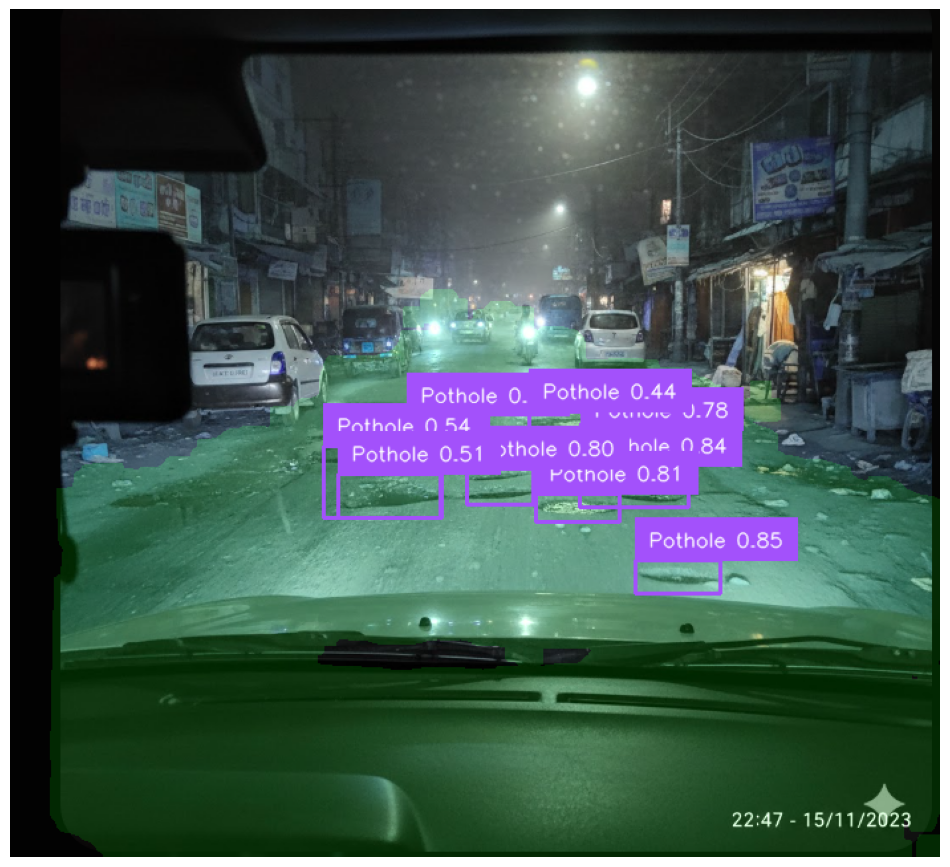

Filtered 0 off-road false positives!


In [22]:
IMAGE_PATH = "/content/Screenshot 2026-02-25 142025.png"
OUTPUT_IMAGE_PATH = "output/filtered_inference_result.jpg"

image = Image.open(IMAGE_PATH).convert("RGB")
scene = np.array(image)

# 1. Get Road Mask
road_mask = get_road_mask(image, processor, seg_model, DEVICE)

# 2. Get Raw Detections from RF-DETR
raw_detections = det_model.predict(image, threshold=CONF_THRESHOLD)

# 3. Apply the Spatial Filter (Discard trees/off-road)
filtered_detections = filter_detections_by_road(raw_detections, road_mask, overlap_threshold=0.3)

# 4. Visualization
# (Optional) Lightly shade the road green so you can visually verify the segmentation
color_mask = np.zeros_like(scene)
color_mask[road_mask == 1] = [0, 255, 0]
annotated_scene = cv2.addWeighted(scene, 1.0, color_mask, 0.15, 0) # 15% opacity green

# Annotators
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
labels =[f"Pothole {conf:.2f}" for conf in filtered_detections.confidence]

# Draw Boxes
annotated_scene = box_annotator.annotate(scene=annotated_scene, detections=filtered_detections)
annotated_scene = label_annotator.annotate(scene=annotated_scene, detections=filtered_detections, labels=labels)

# Display and Save
sv.plot_image(annotated_scene)
import os
os.makedirs("output", exist_ok=True)
Image.fromarray(annotated_scene).save(OUTPUT_IMAGE_PATH)
print(f"Filtered {len(raw_detections) - len(filtered_detections)} off-road false positives!")

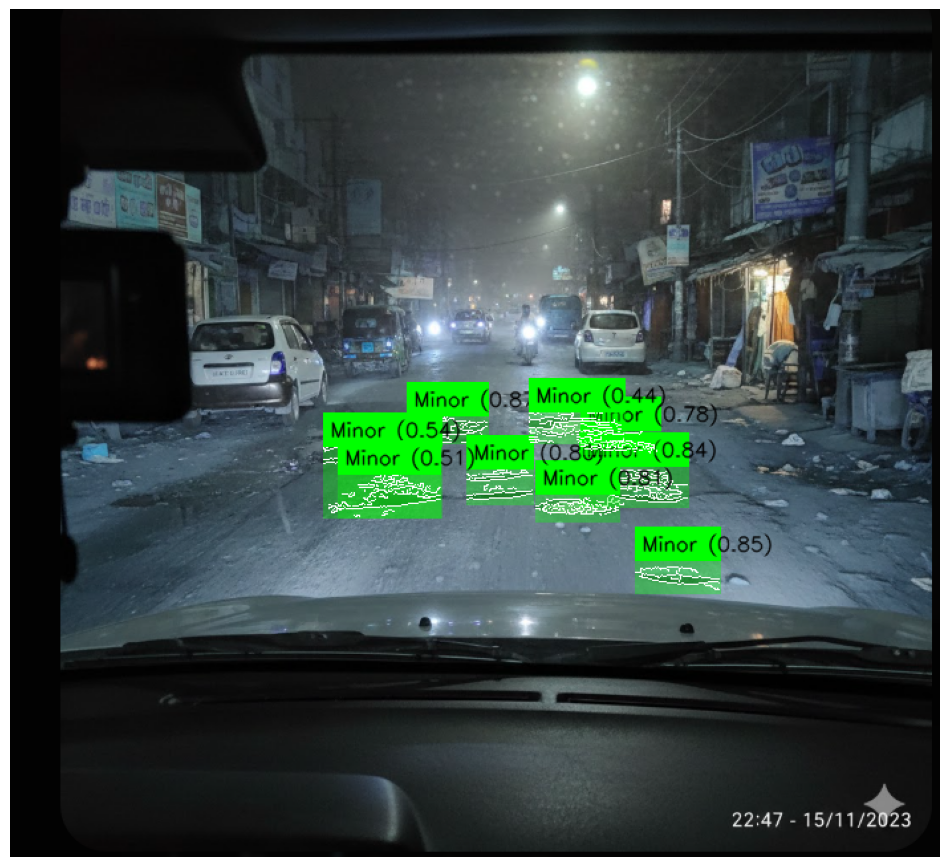

✅ Pothole severity visualization complete.


In [23]:
import os
os.makedirs("output", exist_ok=True)

annotated_scene = scene.copy()

# For normalization
image_area = scene.shape[0] * scene.shape[1]

for box, conf in zip(filtered_detections.xyxy, filtered_detections.confidence):
    x1, y1, x2, y2 = map(int, box)

    # Ensure bounds
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(scene.shape[1], x2), min(scene.shape[0], y2)

    pothole_crop = scene[y1:y2, x1:x2]

    if pothole_crop.size == 0:
        continue

    # --------------------------
    # 1️⃣ EDGE DETECTION
    # --------------------------
    gray = cv2.cvtColor(pothole_crop, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    edge_density = np.sum(edges > 0) / edges.size

    # --------------------------
    # 2️⃣ WIDTH ESTIMATION (Area based)
    # --------------------------
    box_area = (x2 - x1) * (y2 - y1)
    normalized_area = box_area / image_area

    # --------------------------
    # 3️⃣ SEVERITY SCORE
    # --------------------------
    severity_score = 0.6 * normalized_area + 0.4 * edge_density

    if severity_score < 0.3:
        severity_label = "Minor"
        color = (0, 255, 0)       # Green
    elif severity_score < 0.6:
        severity_label = "Moderate"
        color = (0, 255, 255)     # Yellow
    else:
        severity_label = "Severe"
        color = (0, 0, 255)       # Red

    # --------------------------
    # 4️⃣ TRANSLUCENT MASK
    # --------------------------
    overlay = annotated_scene.copy()
    cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
    annotated_scene = cv2.addWeighted(overlay, 0.35, annotated_scene, 0.65, 0)

    # Draw edges inside box (optional but cool)
    edge_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    annotated_scene[y1:y2, x1:x2] = np.where(
        edge_rgb > 0,
        [255, 255, 255],
        annotated_scene[y1:y2, x1:x2]
    )

    # --------------------------
    # 5️⃣ LABEL
    # --------------------------
    label = f"{severity_label} ({conf:.2f})"
    cv2.rectangle(annotated_scene, (x1, y1-25), (x2, y1), color, -1)
    cv2.putText(
        annotated_scene,
        label,
        (x1+5, y1-7),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 0),
        1,
        cv2.LINE_AA
    )

# Show and save
sv.plot_image(annotated_scene)
Image.fromarray(annotated_scene).save("output/pothole_severity_result.jpg")

print("✅ Pothole severity visualization complete.")

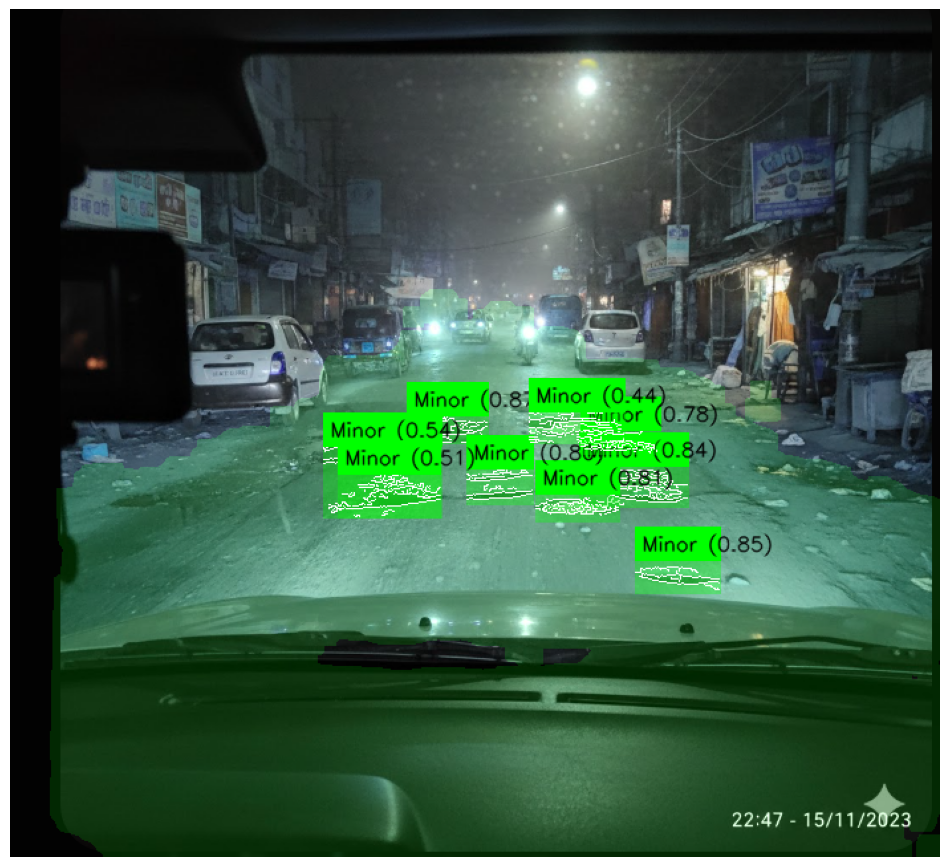

✅ Road segmentation + severity visualization complete.


In [24]:
import os
os.makedirs("output", exist_ok=True)

# Copy original scene
annotated_scene = scene.copy()

# ----------------------------
# 1️⃣ ROAD SEGMENTATION OVERLAY (UNCHANGED)
# ----------------------------
color_mask = np.zeros_like(scene)
color_mask[road_mask == 1] = [0, 255, 0]  # Green road
annotated_scene = cv2.addWeighted(annotated_scene, 1.0, color_mask, 0.15, 0)

image_area = scene.shape[0] * scene.shape[1]

# ----------------------------
# 2️⃣ PROCESS EACH FILTERED POTHOLE
# ----------------------------
for box, conf in zip(filtered_detections.xyxy, filtered_detections.confidence):

    x1, y1, x2, y2 = map(int, box)

    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(scene.shape[1], x2), min(scene.shape[0], y2)

    pothole_crop = scene[y1:y2, x1:x2]

    if pothole_crop.size == 0:
        continue

    # ----------------------------
    # 3️⃣ EDGE DETECTION
    # ----------------------------
    gray = cv2.cvtColor(pothole_crop, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    edge_density = np.sum(edges > 0) / edges.size

    # ----------------------------
    # 4️⃣ SIZE ESTIMATION
    # ----------------------------
    box_area = (x2 - x1) * (y2 - y1)
    normalized_area = box_area / image_area

    # ----------------------------
    # 5️⃣ SEVERITY SCORE
    # ----------------------------
    severity_score = 0.6 * normalized_area + 0.4 * edge_density

    if severity_score < 0.3:
        severity_label = "Minor"
        color = (0, 255, 0)       # Green
    elif severity_score < 0.6:
        severity_label = "Moderate"
        color = (0, 255, 255)     # Yellow
    else:
        severity_label = "Severe"
        color = (0, 0, 255)       # Red

    # ----------------------------
    # 6️⃣ TRANSLUCENT POTHOLE MASK
    # ----------------------------
    overlay = annotated_scene.copy()
    cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
    annotated_scene = cv2.addWeighted(overlay, 0.35, annotated_scene, 0.65, 0)

    # ----------------------------
    # 7️⃣ EDGE OVERLAY INSIDE BOX
    # ----------------------------
    edge_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    region = annotated_scene[y1:y2, x1:x2]

    # Highlight edges in white
    region[edges > 0] = [255, 255, 255]
    annotated_scene[y1:y2, x1:x2] = region

    # ----------------------------
    # 8️⃣ LABEL
    # ----------------------------
    label = f"{severity_label} ({conf:.2f})"
    cv2.rectangle(annotated_scene, (x1, y1 - 25), (x2, y1), color, -1)
    cv2.putText(
        annotated_scene,
        label,
        (x1 + 5, y1 - 7),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 0),
        1,
        cv2.LINE_AA
    )

# ----------------------------
# 9️⃣ DISPLAY + SAVE
# ----------------------------
sv.plot_image(annotated_scene)
Image.fromarray(annotated_scene).save("output/pothole_severity_result.jpg")

print("✅ Road segmentation + severity visualization complete.")

In [19]:
SOURCE_VIDEO_PATH = "/content/IndianPotholes_Dashcam_2.mp4"
TARGET_VIDEO_PATH = "output/IndianPotholes_Dashcam_2_result.mp4"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# OPTIMIZATION: Only run Segformer every 3 frames and reuse the mask.
# Drastically improves FPS without losing filtering accuracy.
MASK_UPDATE_FREQ = 3
current_road_mask = None

print(f"Processing video: {video_info.width}x{video_info.height} at {video_info.fps} FPS")

with sv.VideoSink(target_path=TARGET_VIDEO_PATH, video_info=video_info) as sink:

    for i, frame in enumerate(tqdm(generator, total=video_info.total_frames, desc="Running Inference")):

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)

        # 1. Update Road mask periodically
        if i % MASK_UPDATE_FREQ == 0 or current_road_mask is None:
            current_road_mask = get_road_mask(pil_image, processor, seg_model, DEVICE)

        # 2. RF-DETR Detection
        raw_detections = det_model.predict(pil_image, threshold=CONF_THRESHOLD)

        # 3. Filter using the cached Road Mask
        filtered_detections = filter_detections_by_road(raw_detections, current_road_mask, overlap_threshold=0.3)

        # 4. Annotate
        labels =[f"Pothole {conf:.2f}" for conf in filtered_detections.confidence]
        annotated_frame = frame.copy()

        # Optional debug view: uncomment lines below to see a green hue on detected road
        # mask_overlay = np.zeros_like(annotated_frame)
        # mask_overlay[current_road_mask == 1] =[0, 255, 0] # Green in BGR
        # annotated_frame = cv2.addWeighted(annotated_frame, 1.0, mask_overlay, 0.15, 0)

        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=filtered_detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=filtered_detections, labels=labels)

        # 5. Write Frame
        sink.write_frame(frame=annotated_frame)

print(f"Done! Saved to {TARGET_VIDEO_PATH}")

Processing video: 1080x1920 at 30 FPS


Running Inference: 100%|██████████| 364/364 [01:08<00:00,  5.33it/s]

Done! Saved to output/IndianPotholes_Dashcam_2_result.mp4
